# 🌸 Iris Dataset Clustering with K-Means & GMM

This notebook demonstrates **unsupervised clustering** on the classic Iris dataset using two approaches:

- **K-Means Clustering** — partition-based algorithm
- **Gaussian Mixture Model (GMM)** — probabilistic model-based approach

## Workflow
1. Data loading & exploration
2. Preprocessing & feature scaling
3. Optimal cluster selection (Elbow Method + Silhouette Score)
4. K-Means clustering
5. GMM clustering
6. Comparison of predictions vs. ground truth

---
> **Dataset:** [Iris Dataset](https://www.kaggle.com/datasets/uciml/iris) — 150 samples, 4 numeric features, 3 species

## 1. Import Libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

# Display settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Load & Inspect the Data

In [ ]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [11]:
# Drop the non-informative Id column
df.drop("Id", axis=1, inplace=True)

print(f"Unique species: {df.Species.nunique()}")
print(df.Species.value_counts())

Unique species: 3
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 3. Data Cleaning

In [12]:
print(f"Duplicate rows: {df.duplicated().sum()}")

# Remove duplicates
df = df[~df.duplicated()]
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 3
Shape after removing duplicates: (147, 5)


## 4. Exploratory Data Analysis (EDA)

We examine the distribution and skewness of each numeric feature, and visualise how each feature separates the species.

In [13]:
num_col = df.select_dtypes("number")
num_col.describe().T

,count,mean,std,min,25%,50%,75%,max
SepalLengthCm,147.0,5.856463,0.829100,4.3,5.1,5.8,6.4,7.9
SepalWidthCm,147.0,3.055782,0.437009,2.0,2.8,3.0,3.3,4.4
PetalLengthCm,147.0,3.780272,1.759111,1.0,1.6,4.4,5.1,6.9
PetalWidthCm,147.0,1.208844,0.757874,0.1,0.3,1.3,1.8,2.5



Feature: SepalLengthCm  |  Skew: 0.29


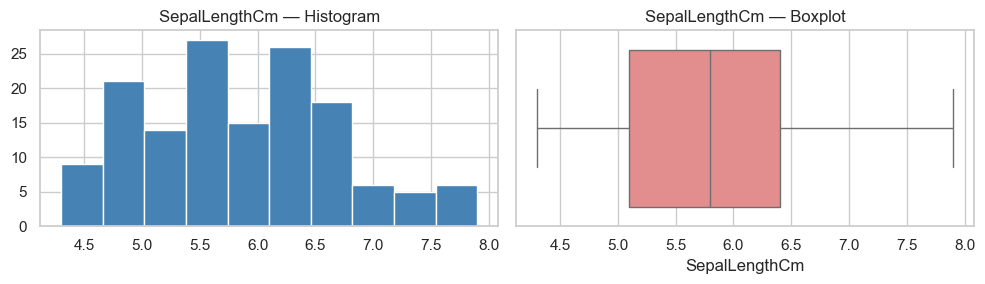


Feature: SepalWidthCm  |  Skew: 0.32


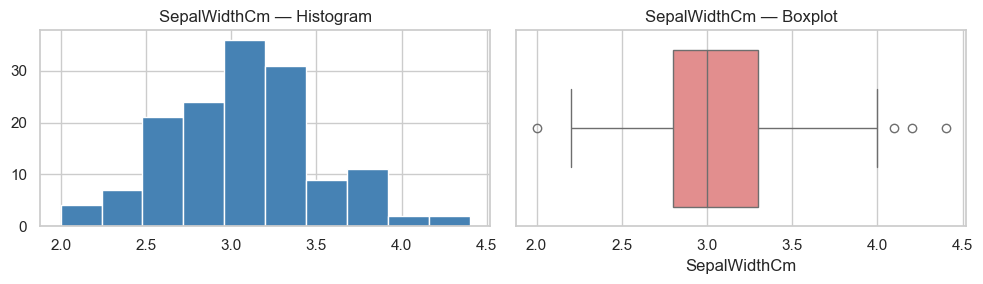


Feature: PetalLengthCm  |  Skew: -0.29


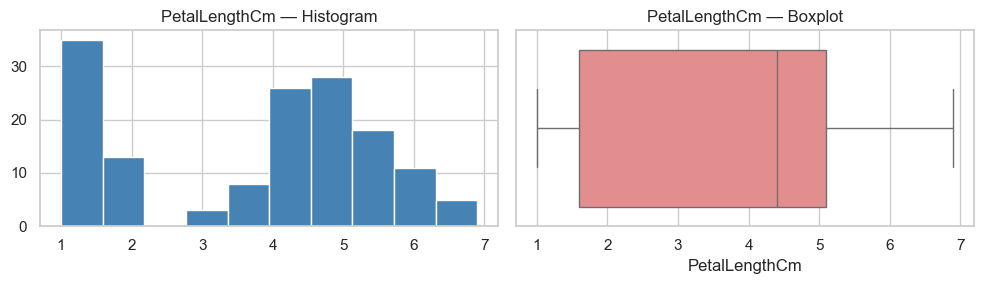


Feature: PetalWidthCm  |  Skew: -0.11


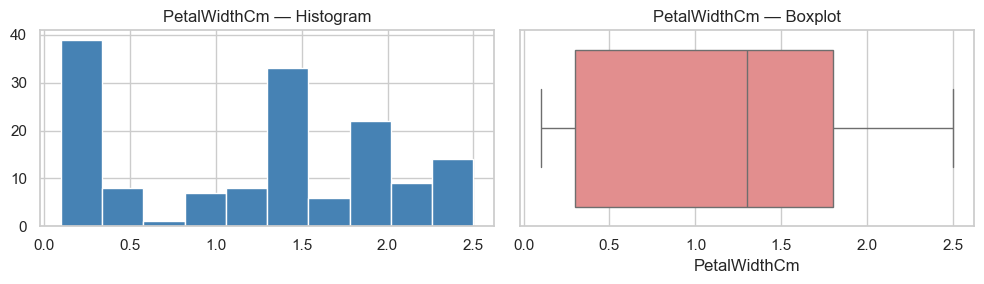

In [14]:
# Histogram + boxplot for each numeric feature
for col in num_col:
    print(f"\nFeature: {col}  |  Skew: {np.round(df[col].skew(), 2)}")
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    df[col].hist(ax=axes[0], color="steelblue", edgecolor="white")
    axes[0].set_title(f"{col} — Histogram")
    sns.boxplot(x=df[col], ax=axes[1], color="lightcoral")
    axes[1].set_title(f"{col} — Boxplot")
    plt.tight_layout()
    plt.show()

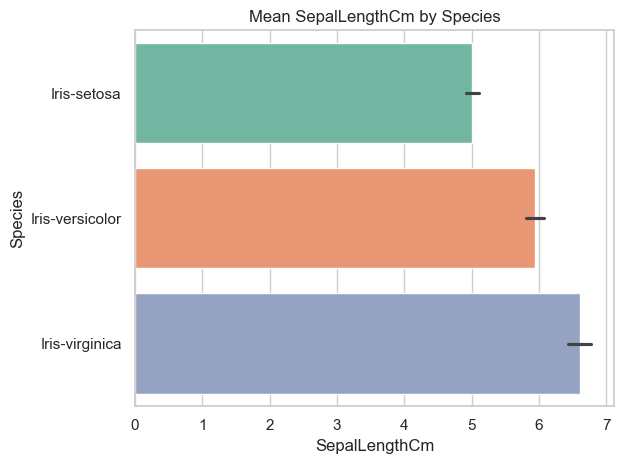

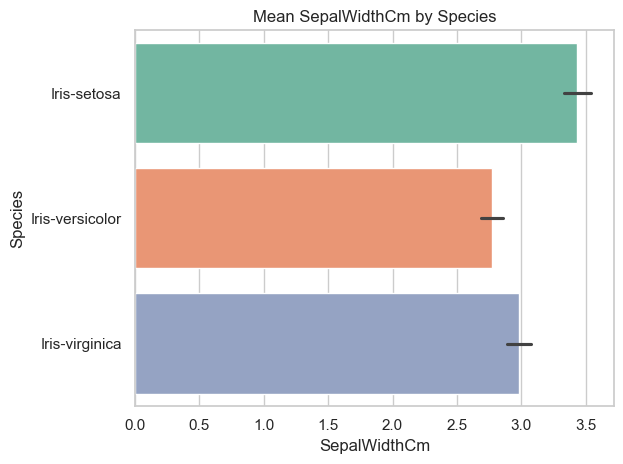

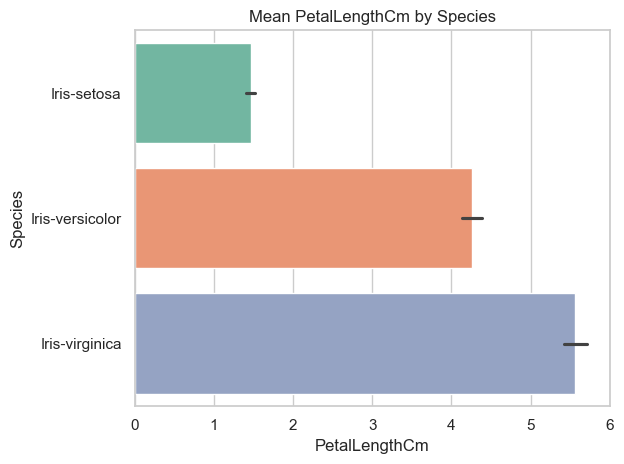

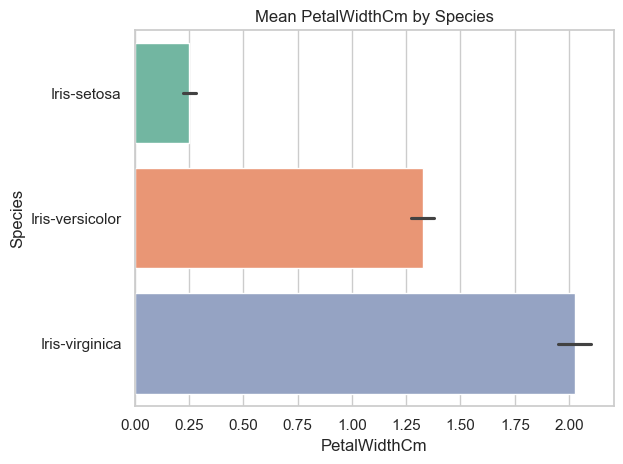

In [15]:
# Bar plots — feature value by species
for col in num_col:
    sns.barplot(df, x=col, y="Species", palette="Set2")
    plt.title(f"Mean {col} by Species")
    plt.tight_layout()
    plt.show()

## 5. Feature Scaling

K-Means uses Euclidean distance, so features must be on the same scale.
We apply **StandardScaler** (zero mean, unit variance).

In [16]:
from sklearn.preprocessing import StandardScaler

# Save species labels before dropping
df_species = df.Species.copy()
df.drop("Species", axis=1, inplace=True)

ss = StandardScaler()
df_scaled = pd.DataFrame(ss.fit_transform(df), columns=df.columns)

df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
SepalLengthCm,147.0,-4.833624e-17,1.003419,-1.883710,-0.915509,-0.068334,0.657817,2.473193
SepalWidthCm,147.0,1.691768e-16,1.003419,-2.424189,-0.587304,-0.128082,0.560750,3.086468
PetalLengthCm,147.0,-2.416812e-16,1.003419,-1.585902,-1.243654,0.353501,0.752789,1.779532
PetalWidthCm,147.0,-3.383537e-16,1.003419,-1.468099,-1.203301,0.120690,0.782686,1.709480


## 6. Optimal Number of Clusters

### 6.1 Elbow Method (WCSS)
Plot the Within-Cluster Sum of Squares for k = 1 … 10 and look for the "elbow".

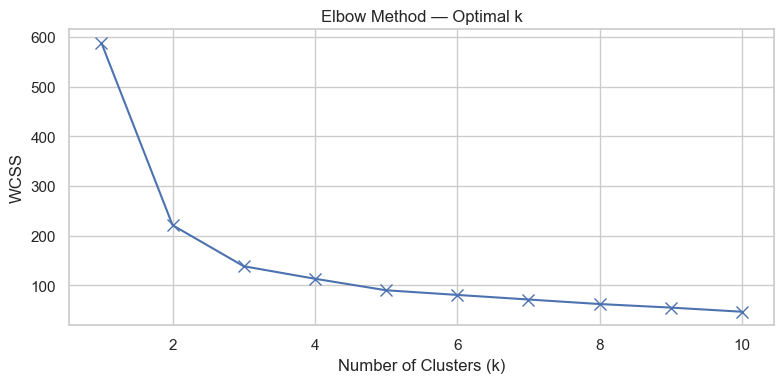

In [17]:
from sklearn.cluster import KMeans

wcss = {}
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    km.fit(df_scaled)
    wcss[k] = km.inertia_

plt.figure(figsize=(8, 4))
plt.plot(list(wcss.keys()), list(wcss.values()), "bx-", markersize=8)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method — Optimal k")
plt.tight_layout()
plt.show()

### 6.2 Silhouette Score
Higher silhouette score → better-defined clusters.

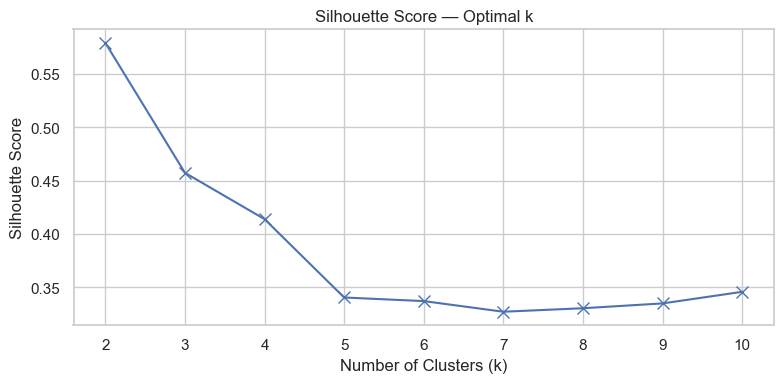

In [25]:
from sklearn.metrics import silhouette_score

sc = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    labels = km.fit_predict(df_scaled)
    sc[k] = silhouette_score(df_scaled, labels)

plt.figure(figsize=(8, 4))
plt.plot(list(sc.keys()), list(sc.values()), "bx-", markersize=8)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score — Optimal k")
plt.tight_layout()
plt.show()

Both methods agree: **k = 3** is the optimal number of clusters, which aligns with the 3 known Iris species.

## 7. K-Means Clustering (k = 3)

In [19]:
kmeans = KMeans(n_clusters=3, random_state=1, n_init=10)
kmeans.fit(df_scaled)

df["Kmeans Prediction"] = kmeans.predict(df_scaled)
df["Species"] = df_species.values

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Kmeans Prediction,Species
0,5.1,3.5,1.4,0.2,1,Iris-setosa
1,4.9,3.0,1.4,0.2,1,Iris-setosa
2,4.7,3.2,1.3,0.2,1,Iris-setosa
3,4.6,3.1,1.5,0.2,1,Iris-setosa
4,5.0,3.6,1.4,0.2,1,Iris-setosa


### 7.1 Confusion Matrix — K-Means vs Ground Truth

In [20]:
comparison = pd.crosstab(df["Species"], df["Kmeans Prediction"],
                         rownames=["Actual Species"],
                         colnames=["K-Means Cluster"])
print(comparison)

K-Means Cluster   0   1   2
Actual Species             
Iris-setosa       0  48   0
Iris-versicolor  11   0  39
Iris-virginica   36   0  13


### 7.2 Scatter Plot — Predictions vs Actual (Petal Length × Petal Width)

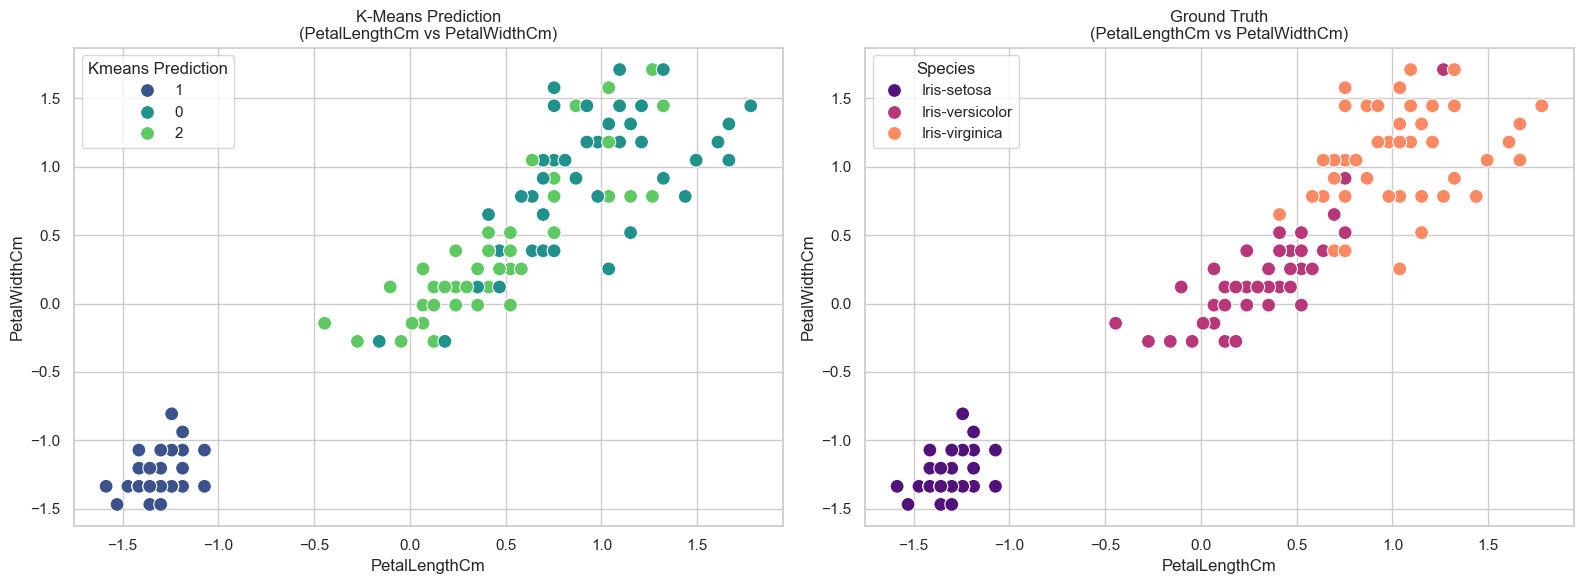

In [21]:
col_x = df_scaled.columns[2]  # Petal Length
col_y = df_scaled.columns[3]  # Petal Width

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(ax=axes[0], x=df_scaled[col_x], y=df_scaled[col_y],
                hue=df["Kmeans Prediction"].astype(str),
                palette="viridis", s=100)
axes[0].set_title(f"K-Means Prediction\n({col_x} vs {col_y})")

sns.scatterplot(ax=axes[1], x=df_scaled[col_x], y=df_scaled[col_y],
                hue=df["Species"], palette="magma", s=100)
axes[1].set_title(f"Ground Truth\n({col_x} vs {col_y})")

plt.tight_layout()
plt.show()

## 8. Gaussian Mixture Model (GMM)

GMM is a soft clustering algorithm — each point has a probability of belonging to each cluster, rather than a hard assignment.

In [22]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=1)
gmm.fit(df_scaled)
df["GMM Predict"] = gmm.predict(df_scaled)

### 8.1 Confusion Matrix — GMM vs Ground Truth

In [23]:
pred = pd.crosstab(df["Species"], df["GMM Predict"],
                   rownames=["Actual Species"],
                   colnames=["GMM Cluster"])
print(pred)

GMM Cluster       0   1   2
Actual Species             
Iris-setosa       0  48   0
Iris-versicolor   5   0  45
Iris-virginica   49   0   0


### 8.2 Scatter Plot — GMM Predictions vs Actual

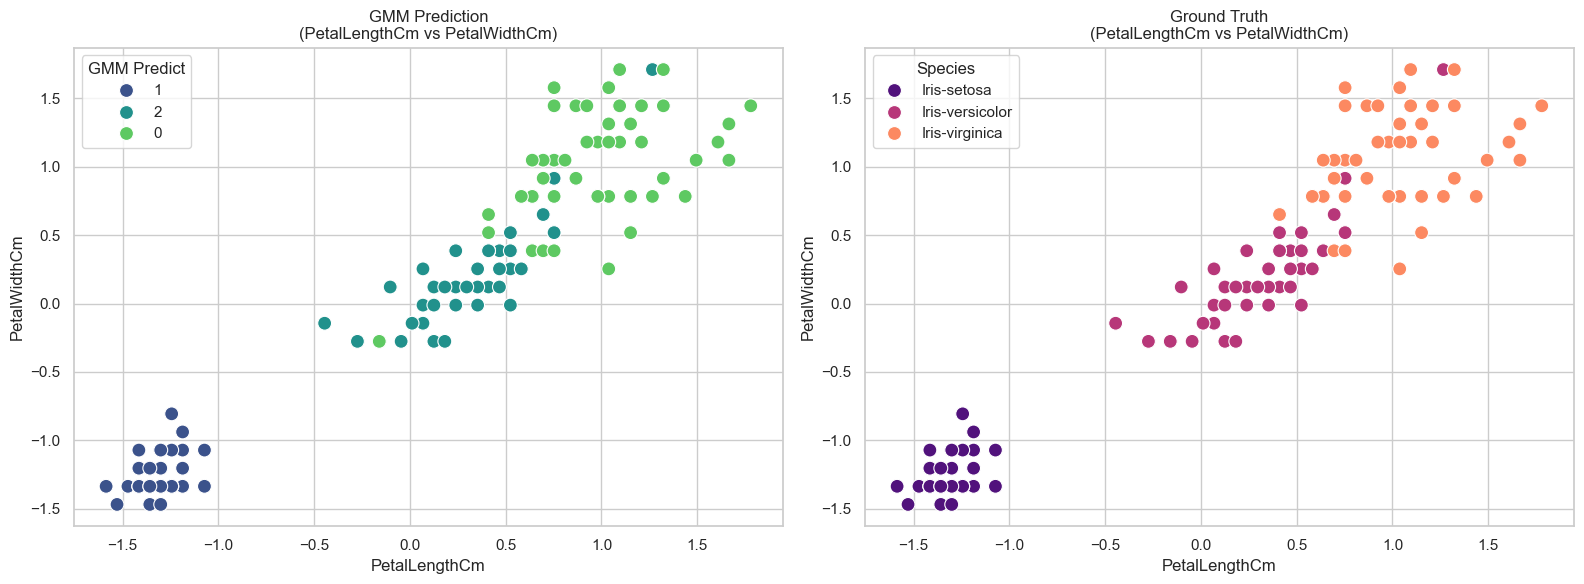

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(ax=axes[0], x=df_scaled[col_x], y=df_scaled[col_y],
                hue=df["GMM Predict"].astype(str),
                palette="viridis", s=100)
axes[0].set_title(f"GMM Prediction\n({col_x} vs {col_y})")

sns.scatterplot(ax=axes[1], x=df_scaled[col_x], y=df_scaled[col_y],
                hue=df["Species"], palette="magma", s=100)
axes[1].set_title(f"Ground Truth\n({col_x} vs {col_y})")

plt.tight_layout()
plt.show()

## 9. Conclusion

| Model | Approach | Notes |
|-------|----------|-------|
| **K-Means** | Hard assignment | Fast, deterministic, sensitive to outliers |
| **GMM** | Soft (probabilistic) | More flexible cluster shapes, slightly higher accuracy on Iris |

**Key takeaways:**
- Both models correctly isolate *Iris setosa* (perfectly separable).
- *Iris versicolor* and *Iris virginica* overlap slightly — both models occasionally misassign a few samples.
- Petal Length and Petal Width are the most discriminative features.
- Since the true number of species is 3, k = 3 was confirmed by both the Elbow Method and the Silhouette Score.